# Regresión polinómica con interacción para luminosidad estelar

## Configuración inicial

In [4]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt


## 1. Visualización de datos

In [6]:

M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])


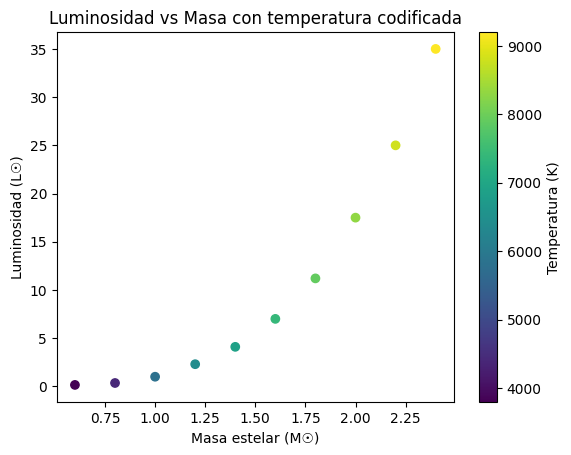

In [7]:
plt.figure()
sc = plt.scatter(M, L, c=T)
plt.xlabel("Masa estelar (M☉)")
plt.ylabel("Luminosidad (L☉)")
plt.title("Luminosidad vs Masa con temperatura codificada")
plt.colorbar(sc, label="Temperatura (K)")
plt.show()


La relación entre la masa y la luminosidad no es lineal. A medida que la masa aumenta, la luminosidad crece de forma acelerada.

Además, la temperatura también aumenta con la masa, lo que sugiere que la interacción entre masa y temperatura puede ser relevante. Por esto pasamos a usar términos polinómicos.

## 2. Ingienería de características



\[
X =
\begin{bmatrix}
M ,& T, & M^2, & M °T
\end{bmatrix}
\]


In [8]:
X = np.column_stack([
    M,
    T,
    M**2,
    M * T
])


## 3. Perdida y gradientes (Vectorizados)

In [9]:
def predecir(X, w, b):
    return X @ w + b
def mse(y, y_hat):
    return np.mean((y - y_hat)**2)


In [10]:
def gradientes(X, y, w, b):
    n = len(y)
    
    y_hat = predecir(X, w, b)
    error = y_hat - y
    
    dw = (2 / n) * X.T @ error
    db = (2 / n) * np.sum(error)
    
    return dw, db


## 4. Descenso de gradiente + convergencia

In [11]:

media_X = X.mean(axis=0)
desv_X = X.std(axis=0)
X_escalada = (X - media_X) / desv_X


In [12]:
def descenso_gradiente(X, y, w_inicial, b_inicial, tasa_aprendizaje, num_iteraciones):
    w = w_inicial.copy()
    b = b_inicial

    historial_iteraciones = []
    historial_costo = []

    for i in range(num_iteraciones):
        dw, db = gradientes(X, y, w, b)
        w -= tasa_aprendizaje * dw
        b -= tasa_aprendizaje * db
        if i % 10 == 0 or i == num_iteraciones - 1:
            costo = mse(y, predecir(X, w, b))
            historial_iteraciones.append(i)
            historial_costo.append(costo)
            print(f"Iteración {i:4d}: costo = {costo:8.4f}")

    return w, b, historial_iteraciones, historial_costo


In [13]:
tasa_aprendizaje = 1e-2
num_iteraciones = 1000

w_inicial = np.zeros(X_escalada.shape[1])
b_inicial = 0.0

w_m3, b_m3, iter_hist, costo_hist = descenso_gradiente(
    X_escalada,
    L,
    w_inicial,
    b_inicial,
    tasa_aprendizaje,
    num_iteraciones
)


Iteración    0: costo = 214.3750
Iteración   10: costo = 104.0919
Iteración   20: costo =  66.1913
Iteración   30: costo =  47.7256
Iteración   40: costo =  36.6364
Iteración   50: costo =  29.3886
Iteración   60: costo =  24.4972
Iteración   70: costo =  21.1408
Iteración   80: costo =  18.8035
Iteración   90: costo =  17.1475
Iteración  100: costo =  15.9484
Iteración  110: costo =  15.0563
Iteración  120: costo =  14.3715
Iteración  130: costo =  13.8273
Iteración  140: costo =  13.3788
Iteración  150: costo =  12.9965
Iteración  160: costo =  12.6602
Iteración  170: costo =  12.3566
Iteración  180: costo =  12.0767
Iteración  190: costo =  11.8146
Iteración  200: costo =  11.5660
Iteración  210: costo =  11.3283
Iteración  220: costo =  11.0995
Iteración  230: costo =  10.8784
Iteración  240: costo =  10.6641
Iteración  250: costo =  10.4558
Iteración  260: costo =  10.2532
Iteración  270: costo =  10.0559
Iteración  280: costo =   9.8636
Iteración  290: costo =   9.6760
Iteración 

In [14]:
print("Parámetros aprendidos:")
print("w =", w_m3)
print("b =", b_m3)



Parámetros aprendidos:
w = [ 1.26022177 -5.62763951  9.66624736  5.22778301]
b = 10.359999982564455


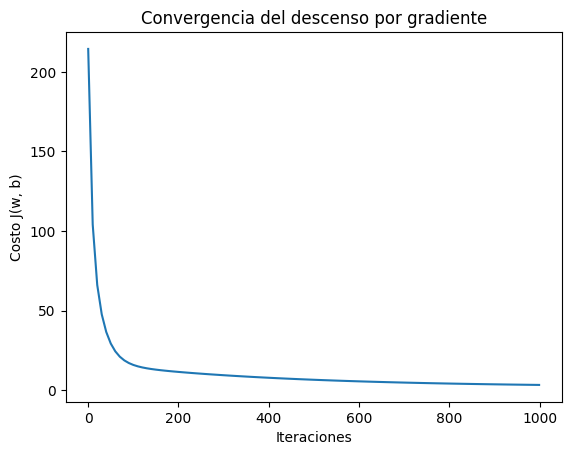

In [15]:
plt.figure()
plt.plot(iter_hist, costo_hist)
plt.xlabel("Iteraciones")
plt.ylabel("Costo J(w, b)")
plt.title("Convergencia del descenso por gradiente")
plt.show()


## 5. Experimento de selección de características

In [19]:

X_M1 = np.column_stack([M, T])
X_M2 = np.column_stack([M, T, M**2])
X_M3 = np.column_stack([M, T, M**2, M*T])


In [20]:
def entrenar_y_evaluar_modelo(X, y, nombre_modelo,
                              tasa_aprendizaje=1e-2,
                              num_iteraciones=1000):
    
    media = X.mean(axis=0)
    desv = X.std(axis=0)
    X_escalada = (X - media) / desv


    w_inicial = np.zeros(X_escalada.shape[1])
    b_inicial = 0.0

    w, b, iter_hist, costo_hist = descenso_gradiente(
        X_escalada, y, w_inicial, b_inicial,
        tasa_aprendizaje, num_iteraciones
    )

    y_pred = predecir(X_escalada, w, b)
    costo_final = costo_hist[-1]

    print(f"\nModelo {nombre_modelo}")
    print("Costo final:", costo_final)
    print("Pesos aprendidos:", w)
    print("Bias aprendido:", b)

    plt.figure()
    plt.scatter(y, y_pred)
    plt.plot([y.min(), y.max()], [y.min(), y.max()])
    plt.xlabel("Luminosidad real")
    plt.ylabel("Luminosidad predicha")
    plt.title(f"{nombre_modelo}: Predicho vs Real")
    plt.show()

    return costo_final, w, b


Iteración    0: costo = 223.2786
Iteración   10: costo = 137.2099
Iteración   20: costo =  91.2044
Iteración   30: costo =  65.5654
Iteración   40: costo =  50.6837
Iteración   50: costo =  41.7199
Iteración   60: costo =  36.1446
Iteración   70: costo =  32.5814
Iteración   80: costo =  30.2503
Iteración   90: costo =  28.6925
Iteración  100: costo =  27.6290
Iteración  110: costo =  26.8861
Iteración  120: costo =  26.3531
Iteración  130: costo =  25.9585
Iteración  140: costo =  25.6558
Iteración  150: costo =  25.4142
Iteración  160: costo =  25.2136
Iteración  170: costo =  25.0405
Iteración  180: costo =  24.8860
Iteración  190: costo =  24.7442
Iteración  200: costo =  24.6111
Iteración  210: costo =  24.4840
Iteración  220: costo =  24.3612
Iteración  230: costo =  24.2416
Iteración  240: costo =  24.1243
Iteración  250: costo =  24.0088
Iteración  260: costo =  23.8947
Iteración  270: costo =  23.7819
Iteración  280: costo =  23.6701
Iteración  290: costo =  23.5593
Iteración 

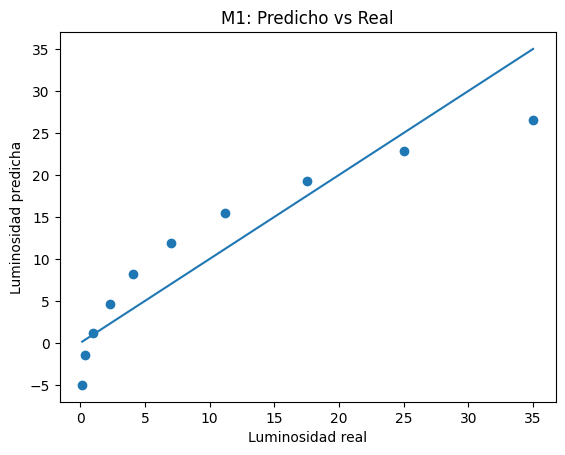

Iteración    0: costo = 218.6620
Iteración   10: costo = 116.2166
Iteración   20: costo =  72.8100
Iteración   30: costo =  51.1812
Iteración   40: costo =  38.8488
Iteración   50: costo =  31.1656
Iteración   60: costo =  26.1250
Iteración   70: costo =  22.7130
Iteración   80: costo =  20.3497
Iteración   90: costo =  18.6766
Iteración  100: costo =  17.4629
Iteración  110: costo =  16.5570
Iteración  120: costo =  15.8585
Iteración  130: costo =  15.3003
Iteración  140: costo =  14.8379
Iteración  150: costo =  14.4415
Iteración  160: costo =  14.0910
Iteración  170: costo =  13.7731
Iteración  180: costo =  13.4789
Iteración  190: costo =  13.2022
Iteración  200: costo =  12.9391
Iteración  210: costo =  12.6868
Iteración  220: costo =  12.4435
Iteración  230: costo =  12.2077
Iteración  240: costo =  11.9787
Iteración  250: costo =  11.7557
Iteración  260: costo =  11.5384
Iteración  270: costo =  11.3264
Iteración  280: costo =  11.1194
Iteración  290: costo =  10.9172
Iteración 

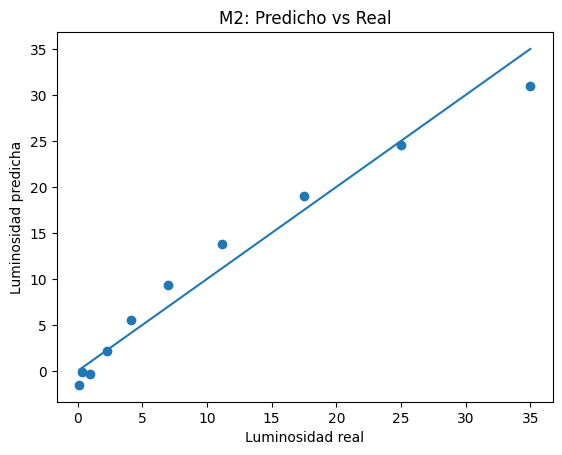

Iteración    0: costo = 214.3750
Iteración   10: costo = 104.0919
Iteración   20: costo =  66.1913
Iteración   30: costo =  47.7256
Iteración   40: costo =  36.6364
Iteración   50: costo =  29.3886
Iteración   60: costo =  24.4972
Iteración   70: costo =  21.1408
Iteración   80: costo =  18.8035
Iteración   90: costo =  17.1475
Iteración  100: costo =  15.9484
Iteración  110: costo =  15.0563
Iteración  120: costo =  14.3715
Iteración  130: costo =  13.8273
Iteración  140: costo =  13.3788
Iteración  150: costo =  12.9965
Iteración  160: costo =  12.6602
Iteración  170: costo =  12.3566
Iteración  180: costo =  12.0767
Iteración  190: costo =  11.8146
Iteración  200: costo =  11.5660
Iteración  210: costo =  11.3283
Iteración  220: costo =  11.0995
Iteración  230: costo =  10.8784
Iteración  240: costo =  10.6641
Iteración  250: costo =  10.4558
Iteración  260: costo =  10.2532
Iteración  270: costo =  10.0559
Iteración  280: costo =   9.8636
Iteración  290: costo =   9.6760
Iteración 

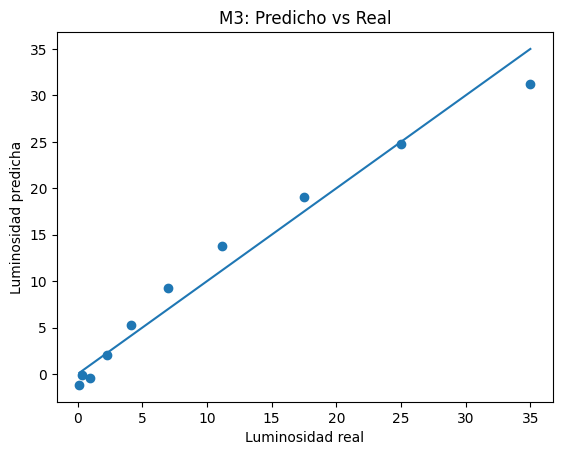

In [21]:
resultados = {}

resultados["M1"] = entrenar_y_evaluar_modelo(X_M1, L, "M1")
resultados["M2"] = entrenar_y_evaluar_modelo(X_M2, L, "M2")
resultados["M3"] = entrenar_y_evaluar_modelo(X_M3, L, "M3")


A partir de los resultados obtenidos se observa que:

- El modelo M1 presenta el mayor error, lo que indica que una relación lineal
  entre masa y temperatura no es suficiente para explicar la luminosidad.
- El modelo M2 mejora el desempeño al incluir el término cuadrático de la masa,
  capturando parcialmente la no linealidad del problema.
- El modelo M3 obtiene el menor valor de la función de costo, demostrando que el término
  de interacción masa–temperatura aporta información relevante.
Esto confirma que la luminosidad estelar depende no solo
de la masa y la temperatura, sino también de su interacción.


## 6. Costo frente a interacción

In [22]:

w_fijo = w_m3.copy()
b_fijo = b_m3


In [23]:
w_MT_min = w_fijo[3] - 1.0
w_MT_max = w_fijo[3] + 1.0
valores_w_MT = np.linspace(w_MT_min, w_MT_max, 100)

In [24]:
costos = []

for valor in valores_w_MT:
    w_temp = w_fijo.copy()
    w_temp[3] = valor 
    
    y_pred = predecir(X_escalada, w_temp, b_fijo)
    costo = mse(L, y_pred)
    costos.append(costo)


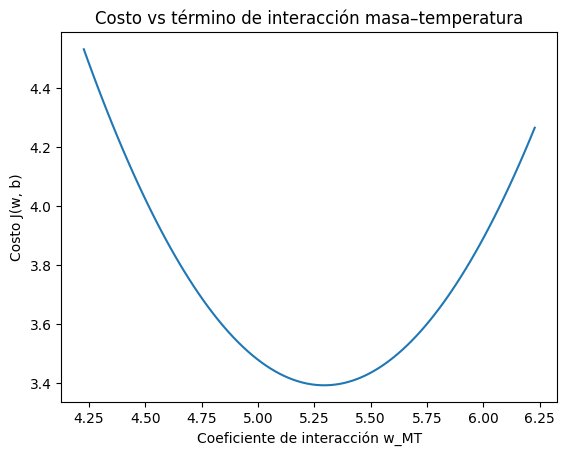

In [25]:
plt.figure()
plt.plot(valores_w_MT, costos)
plt.xlabel("Coeficiente de interacción w_MT")
plt.ylabel("Costo J(w, b)")
plt.title("Costo vs término de interacción masa–temperatura")
plt.show()


La gráfica presenta un mínimo bien definido alrededor del valor entrenado de \(w_{MT}\).
Esto indica que el término de interacción masa–temperatura es relevante para el modelo,
ya que pequeñas variaciones en su coeficiente producen cambios significativos en el costo.

## 7. Demostración de inferencia

In [26]:
M_nueva = 1.3
T_nueva = 6600


In [29]:
X_nueva = np.array([
    M_nueva,
    T_nueva,
    M_nueva**2,
    M_nueva * T_nueva
]).reshape(1, -1)
X_nueva_escalada = (X_nueva - media_X) / desv_X
L_predicha = predecir(X_nueva_escalada, w_m3, b_m3)
L_predicha




array([3.71527848])


La predicción obtenida es razonable, ya que corresponde a una estrella con masa y temperatura intermedias dentro del rango del conjunto de datos utilizado para el entrenamiento.

En el dataset original, estrellas con masas cercanas a 1.2–1.4 masas solares presentan luminosidades del mismo orden de magnitud que la predicha por el modelo. Por lo tanto,
la estimación no constituye una extrapolación extrema y es consistente con el comportamiento esperado de estrellas de la secuencia principal.
